<h1><font color="#113D68" size=5>Redes neuronales convolucionales</font></h1>



<h1><font color="#113D68" size=6>Caso Práctico: análisis de un problema de clasificación de imágenes con Deep Learning</font></h1>


<br><br>
<div style="text-align: right">
<font size=3>Daniel González</font><br>
<font size=3>IEBS</font>
</div>

---
<h2>Autor: Adrián Robles Arques</h2>

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [Caso práctico](#section1)
    - [Parte obligatoria](#section1.1)
    - [Parte opcional](#section1.2)
    - [Objetivos](#section1.3)
    - [Criterios de entrega](#section1.4)
    - [Temporalización](#section1.5)
* [Flickr Style dataset](#section2)
* [Red convolucional desde 0](#section3)
    - [Ejercicio 1](#section3.1)
    - [Ejercicio 2](#section3.2)
* [Red pre-entrenada (InceptionV3)](#section4)
    - [Ejercicio 3](#section4.1)
    - [Ejercicio 4](#section4.2)
    - [Ejercicio 5](#section4.3)
    - [Ejercicio 6](#section4.3)
    - [Ejercicio 7](#section4.4)
    - [Ejercicio 8](#section4.5)
* [Red opcional](#section5)
    - [Ejercicio 7](#section5.1)
* [¿Cuál es el mejor modelo?](#section6)
    - [Ejercicio 8](#section6.1)

In [26]:
import tensorflow as tf
import numpy as np
import pandas as pd

# Para mostrar gráficas
import matplotlib.pyplot as plt
%matplotlib inline

# Anaconda fixing problem
# import os
# os.environ['KMP_DUPLICATE_LIB_OK']='True'

# Establecemos una semilla para numpy y tensorflow para poder reproducir la ejecución y los resultados
seed = 101
np.random.seed(seed)
tf.random.set_seed(seed)

# <font color="#004D7F" size=5>Caso práctico</font>

El objetivo de este caso práctico es simular como se haría un análisis completo de un problema de clasificación de imágenes para resolverlo con Deep Learning. Nos pondremos en la piel de un *data scientist* dedicado a analizar y crear modelos de Deep Learning para pasarlos a producción y ser desplegados en una aplicación.

**Destacar que este caso práctico es la continuación de la actividad de la semana 2. En la actividad de la semana 2 utilizamos el modelo pre-entrendo de InceptionV3 y ahora vamos a realizar más experimentos usando redes convolucionales diseñadas por vosotros.**

Imaginemos que tenemos un dataset completo que queremos explotar, nuestra labor será coger este dataset (Flickr Style dataset) y desde 0 intentar llegar a conseguir un modelo que tenga un buen rendimiento ajustándolo poco a poco como hemos visto en clase. Por lo que tendremos que entrerar distintas redes y comparar los resultados que obtengamos en cada experimento para ver cual es mejor.

Cada experimento que tendremos que realizar estará bien definido, la red que deberéis crear y entrenar será proporcinada por lo que solamente tendréis que crear la red que se nos indica con TensorFlow y realizar el entrenamiento de la misma.

## <font color="#004D7F" size=4>Parte obligatoria</font>

Será obligatorio realizar cada uno de los ejercicios que están definidos. En cada ejercicio está definida la red que se tiene que crear y la configuración con la que se tiene que entrenar, por lo que solamente tendréis que pasar esa definición a código con TensorFlow.

Para tener una buena práctica en la realización de este caso práctico se ofrecen esta recomendaciones:

- Utiliza correctamente el sistema de celdas de jupyter. La libreta está realizada de tal forma que solo tendréis que completar las celdas que se indican, ya sea con código o con texto en markdown. Se recomienda rellenar solamente las celdas indicadas para que quede un informe limpio y fácil de seguir. Si fuera necesario incluir más celdas por cualquier motivo se puede hacer pero realizarlo con cuidado para no ensuciar demasiado la libreta.
<br><br>
- Las redes que tendréis que crear en cada experimento son las vistas en clase, por lo que os podéis inspirar en los ejemplos vistos en los tutoriales. Os recomiendo que no copiéis y peguéis código tal cual, sino que lo escribáis por vuestra cuenta y entendáis lo que estáis haciendo en cada momento. Tomaros el tiempo que haga falta para entender cada paso.
<br><br>
- Comprueba que todo se ejecuta correctamente antes de enviar tu trabajo. La mejor forma de enviarlo es exportando la libreta a pdf o html para enviarla en un formato más profesional.

## <font color="#004D7F" size=4>Parte opcional</font>
La parte opcional es el penúltimo ejercicio donde tendréis volver a aplicar la técnica de _fine-tuning_ eligiendo la red pre-entrenada que vosotros queráis y añadiendo las capas que vosotros elijáis.

## <font color="#004D7F" size=4>Objetivos</font>
* Cargar y entender los datos del dataset Flickr Style con los que se trabajarán.
* Crear cada una de las redes indicadas en los experimentos.
* Entrenar cada una de las redes creadas en los experimentos.
* Entender los resultados obtenidos en cada entrenamiento.

## <font color="#004D7F" size=4>Criterios de entrega</font>
Se deberá entregar una libreta de jupyter, aunque se agradecerá que el formato entregado se html o pdf, el trabajo debe estar autocontenido, incluyendo código y texto explicativo para cada sección. 

<a id="section2"></a>
# <font color="#004D7F" size=5>Flickr Style dataset</font>

Este dataset es el que hemos visto en clase y con el que trabajaremos en el caso práctico. Para refrescarlo, es un dataset que contiene imágenes en color donde queremos clasificar cada imagen según el estilo fotográfico al que pertenece.

El dataset de de imágenes Flickr Style tiene las siguintes características:
- Imágenes de 5 tipos de estilo: Detailed, Pastel, Melancholy, Noir y HDR.
- Imágenes en color, es decir, cada pixel tiene 3 valores entre 0 y 255, esos valores corresponden a los valores de RGB (Red, Green, Blue).
- Imágenes de diferentes tamaños, por lo que tendremos que redimensionarlas al mismo tamaño todas antes de usarlas en nuestro modelo.
- 2.000 imágenes en total para el entrenamiento y para el test.

#### **Imporante!!! Solo ejecutar esta celda una sola vez para descargar los datos, no ejecutarlas si ya tenéis los datos descargados**

In [27]:
!wget 'https://www.dropbox.com/s/ln92e9givhgzugr/flickr_style.zip?dl=0' -O flickr_style.zip
!unzip -q flickr_style.zip
!mkdir data
!mv flickr_style data/

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"unzip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
Ya existe el subdirectorio o el archivo data.
"mv" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


Vamos a cargar los datos de las labels y los datos de las rutas de las imágenes:

In [28]:
# obtenemos el nombre de las primeras etiquetas seleccionadas
style_label_file = 'data/flickr_style/style_names.txt'

# Leemos el archivo de etiquetas y lo guardamos en una lista
with open(style_label_file, 'r') as file:
    style_labels = file.readlines()
style_labels = [label.strip() for label in style_labels]
style_labels

['Detailed', 'Pastel', 'Melancholy', 'Noir', 'HDR']

In [29]:
# cargamos los datos de train
train_frame = pd.read_csv('data/flickr_style/train.txt', sep=" ", header=None)
train_frame.columns = ['files','labels_idx']
train_frame['labels'] = train_frame['labels_idx'].map({i:j for i,j in enumerate(style_labels)})

train_frame.head()

,files,labels_idx,labels
0,data/flickr_style/images/2216312257_2ba4af8439...,3,Noir
1,data/flickr_style/images/1247783411_4b3332a10f...,3,Noir
2,data/flickr_style/images/12981126664_676c39228...,2,Melancholy
3,data/flickr_style/images/1184077873_911026e6ae...,3,Noir
4,data/flickr_style/images/8947602754_24140f40c5...,1,Pastel


In [30]:
# cargamos los datos de test
test_frame = pd.read_csv('data/flickr_style/test.txt', sep=" ", header=None)
test_frame.columns = ['files','labels_idx']
test_frame['labels'] = test_frame['labels_idx'].map({i:j for i,j in enumerate(style_labels)})

test_frame.head()

,files,labels_idx,labels
0,data/flickr_style/images/13059448154_d5ddf02da...,1,Pastel
1,data/flickr_style/images/13091035063_b32ef5213...,2,Melancholy
2,data/flickr_style/images/13230679494_88e5182c8...,4,HDR
3,data/flickr_style/images/12751269395_64f990535...,2,Melancholy
4,data/flickr_style/images/13285760404_05e737a5d...,2,Melancholy


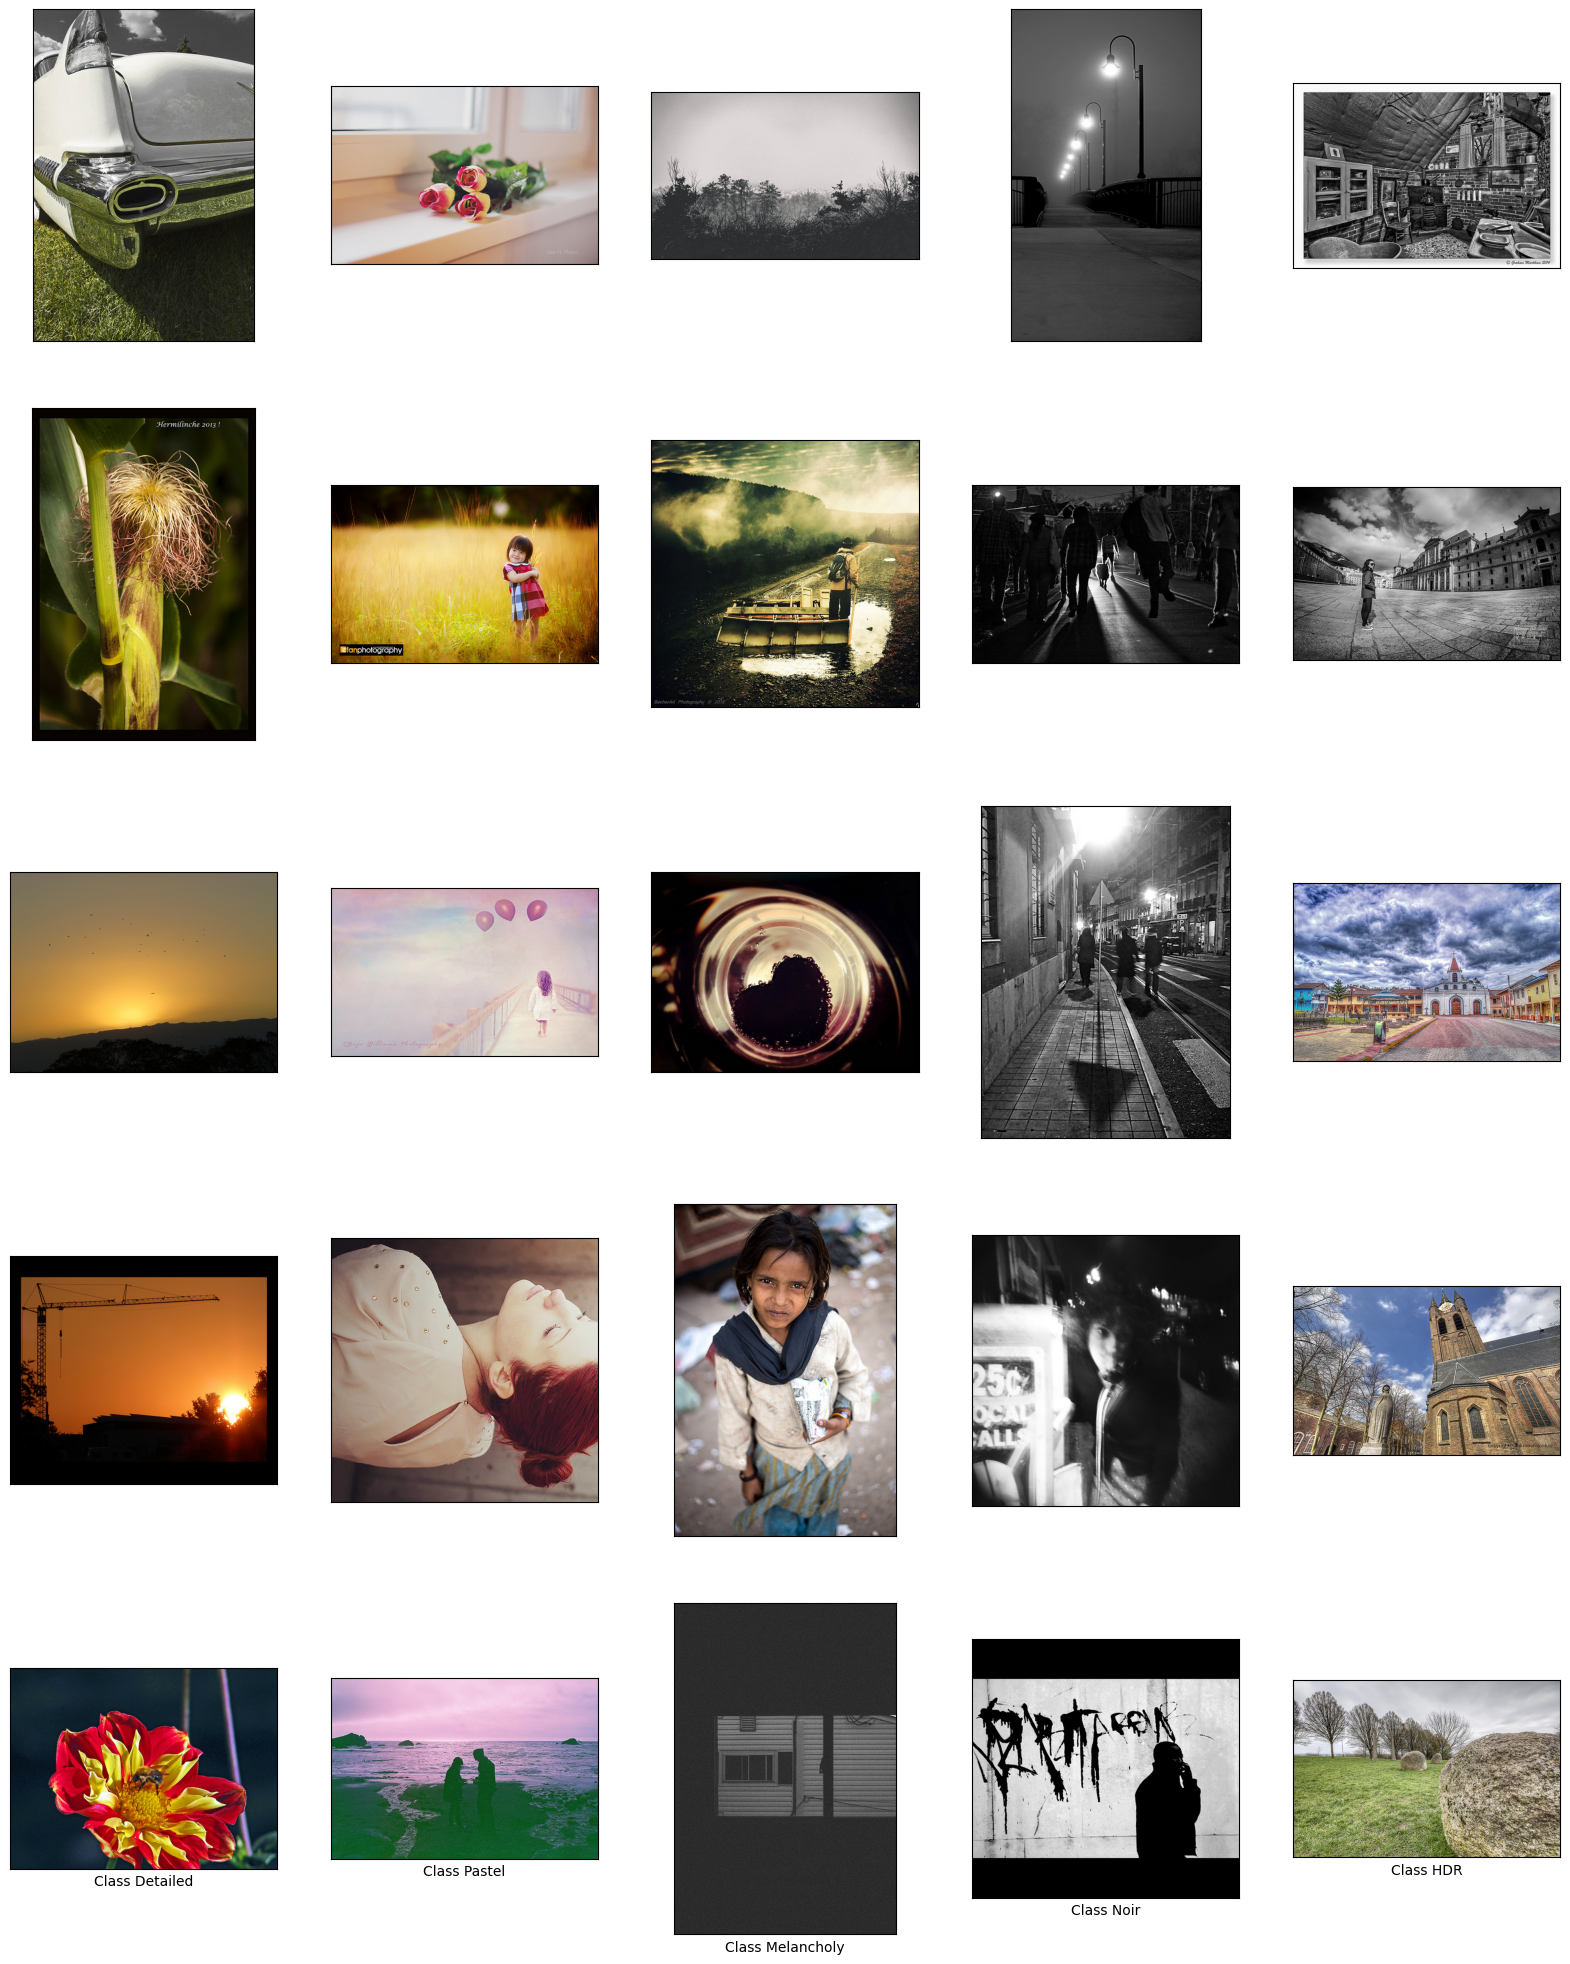

In [31]:
# Mostramos 5 imágenes de cada clase.
plot_n_images = 5
fig = plt.figure(figsize=(20, 25))

np.random.seed(1000)
for i in range(0,5):
    select_frame = train_frame[train_frame['labels_idx']==i]
    for j in range(0,plot_n_images):
        aux_index = np.random.choice(select_frame.index)
        fig_i=fig.add_subplot(plot_n_images,5,j*5+i+1)
        fig_i.imshow(plt.imread(train_frame['files'][aux_index]))
        
        fig_i.set_xticks(())
        fig_i.set_yticks(())
        
    fig_i.set_xlabel('Class %s' % style_labels[i])

<a id="section3"></a>
# <font color="#004D7F" size=5>Red convolucional desde 0</font>

Los primeros experimentos que vamos a realizar será utilizando redes que creemos nosotros mismos. Para ello vamos a tener que transformar las imágense al igual que hicimos en clase, pero esta vez solamente tendremos que realizar estos pasos:

1. Cargar las imágenes
2. Redimensionar todoas las imágenes para tener el mismo tamaño. Usaremos un tamaño de `(150, 150, 3)`.

Como véis, al usar nuestras redes desde 0 no será necesario usar la función `preprocess_input` que tenemos que usar al usar una red pre-entrenada.

La función para transformar las imágenes sería la siguientes:

In [32]:
def load_img(img_path):
    # cargamos y redimensionamos una imágen
    img = tf.keras.utils.load_img(
        img_path,
        target_size=(150, 150, 3) 
    )
    
    # cambiamos el tipo imagen a un numpy.array
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    
    # normalizamos los valores entre 0 y 1
    return img_array / 255

Ahora vamos a cargar las imágenes para poder entrenar nuestras redes convolucionales:

In [33]:
# cargamos las imágenes ya transformadas
x_train = np.array([load_img(img_path) for img_path in train_frame['files']])
x_test = np.array([load_img(img_path) for img_path in test_frame['files']])

# cargamos las clases de cada imagen
y_train = train_frame['labels_idx']
y_test = test_frame['labels_idx']

<a id="section3.1"></a>
### <font color="#004D7F" size=4>Ejercicio 1</font>

Crear una red con la siguiente configuración y entrénala:

Arquitectura de la red:

- Capa convolucional `Conv2D` con 16 filtros/kernels de tamaño `(3,3)`, padding con relleno, activación *ReLU* y con entrada `(150,150,3)`
- Capa pooling `MaxPool2D` con reducción de 2 tanto en tamaño como en desplazamiento (stride) y padding con relleno.
- Capa de aplanado `Flatten`.
- Capa densa `Dense` con 64 neuronas y función de activación _ReLU_.
- Capa densa `Dense` con 32 neuronas y función de activación _ReLU_.
- Capa de salida densa `Dense` con 5 neuronas y función de activación _Softmax_.

Configuración del entrenamiento:

- Optimizador: Adam con factor de entrenamiento 0.001
- Función de error: `sparce_categorical_crossentropy`.
- Métricas: `accuracy`.
- Número de _epochs_: 10
- Validation split: 0.2

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, InputLayer
from tensorflow.keras.optimizers import Adam

In [35]:
# Definimos la arquitectura de la red neuronal
model1 = Sequential([
    InputLayer(shape=(150, 150, 3)),
    Conv2D(16, (3,3), activation='relu', padding='same'),
    MaxPool2D((2, 2), strides=2, padding='same'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')],
    name= 'flickr_style_model1')

model1.summary()
    
    

Model: "flickr_style_model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_94 (Conv2D)              │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 90000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │     5,760,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,762,757 (21.98 MB)

 Trainable params: 5,762,757 (21.98 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Compilamos el modelo
model1.compile(
    optimizer= Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamos el modelo
history1 = model1.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.2325 - loss: 3.5286 - val_accuracy: 0.4440 - val_loss: 1.4571
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5179 - loss: 1.2833 - val_accuracy: 0.4982 - val_loss: 1.3137
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6685 - loss: 0.9379 - val_accuracy: 0.4910 - val_loss: 1.3861
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8105 - loss: 0.6473 - val_accuracy: 0.4982 - val_loss: 1.4964
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8847 - loss: 0.4431 - val_accuracy: 0.4188 - val_loss: 1.8339
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8985 - loss: 0.3642 - val_accuracy: 0.4982 - val_loss: 1.5593
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8890 - loss: 0.3739 - val_accuracy: 0.3718 - val_loss: 2.0841
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9231 - loss: 0.2984 - val_accuracy: 0.4549 - v

Evalua el modelo con el conjunto de test y muestra en una gráfica la evolución del entrenamiento:

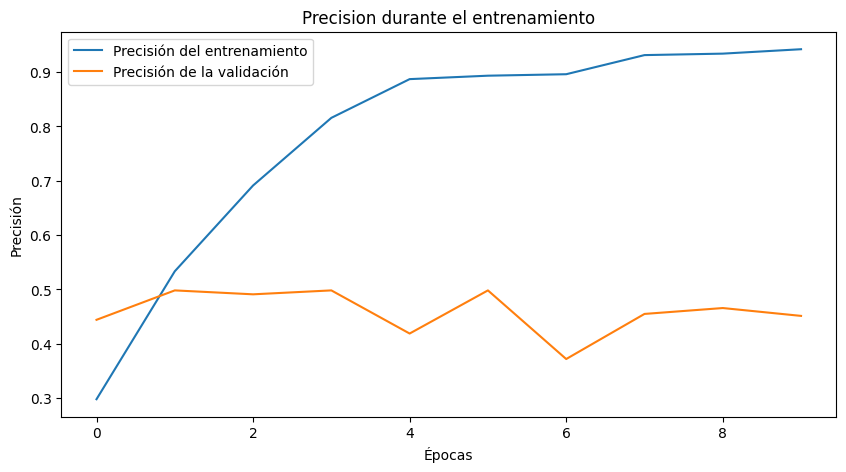

10/10 - 0s - 13ms/step - accuracy: 0.4750 - loss: 2.1600

Precisión del modelo en el conjunto de test: 0.4750


In [37]:
# Mostramos la gráfica de la evolución de la precisión durante el entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(history1.history['accuracy'], label='Precisión del entrenamiento')
plt.plot(history1.history['val_accuracy'], label='Precisión de la validación')
plt.title('Precision durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

# Evaluamos el modelo en el conjunto de test
test_loss, test_accuracy = model1.evaluate(x_test, y_test, verbose=2)
print(f'\nPrecisión del modelo en el conjunto de test: {test_accuracy:.4f}')


Este modelo, a pesar de ser entrenado durante escasas épocas, ya muestra un notable problema de sobreentenado. Como podemos apreciar en la gráfica de evolución de la precisión a lo largo de las épocas, la curva correspondiente a la partición de validación se estanca pronto en torno al 50% de precisión, mientras que la correspondiente al grupo de entrenamiento continúa creciendo hasta alcanzar el 90%. Como vemos en la evaluación de los datos de test, el resultado arroja una precisión cercana al 45%, lo que nos indica un resultado muy pobre.

<a id="section3.2"></a>
### <font color="#004D7F" size=4>Ejercicio 2</font>

Crear una red con la siguiente configuración y entrénala:

Arquitectura de la red:

- Capa convolucional `Conv2D` con 64 filtros/kernels de tamaño `(3,3)`, padding con relleno, activación *ReLU* y con entrada `(150,150,3)`
- Capa pooling `MaxPool2D` con reducción de 2 tanto en tamaño como en desplazamiento (stride) y padding con relleno.
- Capa convolucional `Conv2D` con 32 filtros/kernels de tamaño `(3,3)`, padding con relleno, activación *ReLU*
- Capa pooling `MaxPool2D` con reducción de 2 tanto en tamaño como en desplazamiento (stride) y padding con relleno.
- Capa convolucional `Conv2D` con 32 filtros/kernels de tamaño `(3,3)`, padding con relleno, activación *ReLU*
- Capa pooling `MaxPool2D` con reducción de 2 tanto en tamaño como en desplazamiento (stride) y padding con relleno.
- Capa de aplanado `Flatten`.
- Capa densa `Dense` con 64 neuronas y función de activación _ReLU_.
- Capa `Dropout` con un valor de `0.75`.
- Capa densa `Dense` con 32 neuronas y función de activación _ReLU_.
- Capa densa `Dense` con 32 neuronas y función de activación _ReLU_.
- Capa `Dropout` con un valor de `0.6`.
- Capa de salida densa `Dense` con 10 neuronas y función de activación _Softmax_.

Configuración del entrenamiento:

- Optimizador: Adam con factor de entrenamiento 0.001
- Función de error: `sparce_categorical_crossentropy`.
- Métricas: `accuracy`.
- Número de _epochs_: 50
- Validation split: 0.2

In [38]:
# Definimos la arquitectura de la segunda red neuronal
model2 = Sequential([
    InputLayer(shape=(150, 150, 3)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPool2D((2, 2), strides=2, padding='same'),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPool2D((2, 2), strides=2, padding='same'),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPool2D((2, 2), strides=2, padding='same'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.75),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.6),
    Dense(5, activation='softmax')],
    name= 'flickr_style_model2')

model2.summary()

Model: "flickr_style_model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_95 (Conv2D)              │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 75, 75, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 38, 38, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 38, 38, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 19, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 11552)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │       739,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 772,197 (2.95 MB)

 Trainable params: 772,197 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

Evalua el modelo con el conjunto de test y muestra en una gráfica la evolución del entrenamiento:

In [39]:
# Compilamos el modelo
model2.compile(
    optimizer= Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamos el modelo
history2 = model2.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.2094 - loss: 1.6229 - val_accuracy: 0.1949 - val_loss: 1.6090
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - accuracy: 0.2309 - loss: 1.6051 - val_accuracy: 0.2671 - val_loss: 1.5928
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.2269 - loss: 1.5934 - val_accuracy: 0.3069 - val_loss: 1.5568
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - accuracy: 0.3219 - loss: 1.5697 - val_accuracy: 0.3394 - val_loss: 1.5364
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.3240 - loss: 1.5599 - val_accuracy: 0.3141 - val_loss: 1.5320
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - accuracy: 0.3375 - loss: 1.5467 - val_accuracy: 0.3177 - val_loss: 1.5178
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - accuracy: 0.3381 - loss: 1.5186 - val_accuracy: 0.3249 - val_loss: 1.4967
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - accuracy: 0.3526 - loss: 1.4893 - val_accuracy: 0.

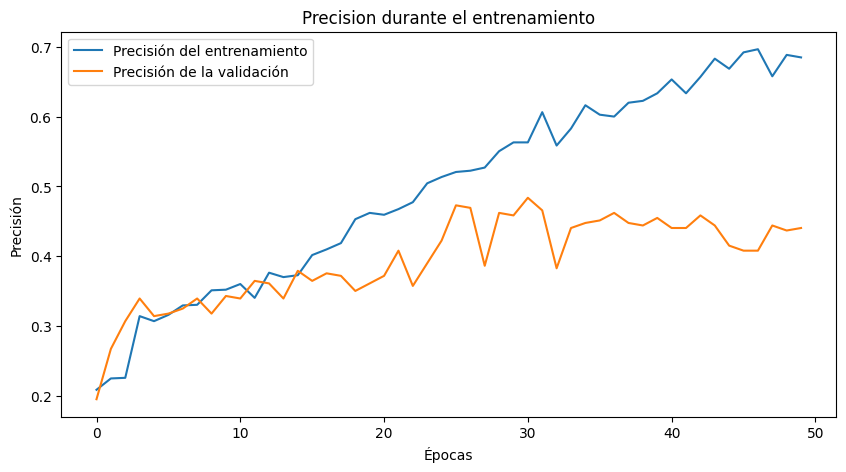

10/10 - 0s - 39ms/step - accuracy: 0.3969 - loss: 1.9936

Precisión del modelo en el conjunto de test: 0.3969


In [40]:
# Mostramos la gráfica de la evolución de la precisión durante el entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(history2.history['accuracy'], label='Precisión del entrenamiento')
plt.plot(history2.history['val_accuracy'], label='Precisión de la validación')
plt.title('Precision durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

# Evaluamos el modelo en el conjunto de test
test_loss, test_accuracy = model2.evaluate(x_test, y_test, verbose=2)
print(f'\nPrecisión del modelo en el conjunto de test: {test_accuracy:.4f}')

Escribe un pequeño texto sacando conclusiones de los resultado obtenidos:

Este modelo, aunque tenga un mayor número de capas, realiza varios pasos de pooling, reduciendo así la dimensionalidad de los datos en mayor medida antes de pasarlos a formato plano. Al realizar esto, puede reducir el número de parámetros entrenables en gran medida, reduciendo el peso del modelo desde algo más de 20 MB a poco más de 2 MB. Además, al añadirle capas de Dropout en la sección full-conected reduce el sobreajuste que veíamos en el caso anterior, que aunque también se produce, se da en menor medida a juzgar por la gráfica. Si es cierto que, visto los resultados de valoración y test, la predicción del modelo no supera al caso anterior, aunque haya pasado por muchas más épocas de entrenamiento. 

<a id="section4"></a>
# <font color="#004D7F" size=5>Red pre-entrenada (InceptionV3)</font>

Ahora vamos a realizar experimento usando la técnica de _fine-tuning_ y utilizando el modelo pre-entrenado de [_InceptionV3_](https://www.tensorflow.org/api_docs/python/tf/keras/applications/inception_v3/InceptionV3).

Los ejercicios siguientes podéis observar que son los mismos ejercicios de la actividad de la semana 2.

<a id="section4.1"></a>
## <font color="#004D7F" size=4>Ejercicio 3: preprocesamiento de las imágenes</font>
Como vamos a usar un modelo pre-entreando tenemos que definir la función que nos transforme las imágenes a utilizar. Como hemos visto en clase, para utilizar las imágenes usando un modelo pre-entrenado es necesario realizar una transformación sobre las imágenes que vamos a utilizar, es decir, tenemos que:

1. Cargar las imágenes
2. Redimensionarlas
3. Usar la función de `preprocess_input` del modelo pre-entrenado que vamos a utilizar.

En este caso vamos a utilizar otro modelo pre-entrado entre los que están disponibles en `tf.keras`, esta vez vamos a usar el modelo de _InceptionV3_, um modelo muy popular y usando frecuentemente. Podéis ver toda la información de este modelo [aquí](https://www.tensorflow.org/api_docs/python/tf/keras/applications/inception_v3/InceptionV3). Este modelo utilizar un tamaño de imagen de _**(299, 299, 3)**_, por lo que tendrás que usar este tamaño en el redimensionamiento.

Como hemos hecho en clase, define una función que se llame `load_img_inceptionv3(img_path)` a la cual le pasamos la ruta donde está alojada una imagen y le realiza todas las transformación necesarias para poder se utilizada luego en el proceso de entrenamiento.

In [41]:
def load_img_inceptionv3(img_path):
    img = tf.keras.utils.load_img(img_path,color_mode='rgb' ,target_size=(299,299,3)) #Cargamos la imagen y la redimensionamos a 299x299
    img = tf.keras.utils.img_to_array(img) # Covertimos la imagen a un array
    img = tf.keras.applications.inception_v3.preprocess_input(img) # Preprocesamos la imagen para la red InceptionV3
    
    return img

**Test**: Puedes probar esta función con el siguiente test, cuando la tengas definida ejecuta la siguiente celda y te debería dar como resultado:

```python
-0.5529412
```

In [42]:
img = load_img_inceptionv3('data/flickr_style/images/2216312257_2ba4af8439.jpg')
img[0,0,0]

np.float32(-0.5529412)

<a id="section4.2"></a>
## <font color="#004D7F" size=4>Ejercicio 4: aplicar el preprocesamiento a todas las imágenes</font>
Una vez tenemos definida nuestra función de para transformar las imágenes, aplíca la transformación tanto al conjunto de train como al conjunto de test como hemos visto en clase.

In [43]:
# cargamos las imágenes de train
x_train_ft = np.array([load_img_inceptionv3(file) for file in train_frame['files'].values])

# cargamos las imágenes de test
x_test_ft = np.array([load_img_inceptionv3(file) for file in test_frame['files'].values])

# cargamos las clases de cada imagen
y_train_ft = np.array(train_frame['labels_idx'].values)
y_test_ft = np.array(test_frame['labels_idx'].values)

**Test**: Puedes probar si lo has hecho correctamente con el siguiente test, cuando hayas terminado ejecuta la siguiente celda y te debería dar como resultado:

```python
(array([-0.5529412, -0.5529412, -0.5372549], dtype=float32), 3)
```

In [44]:
x_train_ft[0,0,0], y_train_ft[0]

(array([-0.5529412, -0.5529412, -0.5372549], dtype=float32), np.int64(3))

<a id="section4.3"></a>
## <font color="#004D7F" size=4>Ejercicio 5: cargar el modelo pre-entrenado InceptionV3</font>
Una vez tenemos los datos listos, vamos a cargar el modelo pre-entrenado de [_InceptionV3_](https://www.tensorflow.org/api_docs/python/tf/keras/applications/inception_v3/InceptionV3).

Como vamos a aplicar _fine-tuning_ recuerda usar los siguientes parámetros:
- `input_shape=(299, 299, 3)`
- `include_top=False`
- `pooling='avg'`

Además tienes que congelar todas las capas para que no se entrenen todas, recureda que solo queremos entrenar las últimas que añadamos nosotros.

In [45]:
# Cargamos el modelo preentrenado InceptionV3
base_model = tf.keras.applications.InceptionV3(input_shape=(299, 299, 3), include_top=False, weights='imagenet', pooling='avg')

# Congelamos las capas del modelo base
base_model.trainable = False

# Mostramos la arquitectura del modelo base
base_model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 149, 149,  │        864 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_99 (Conv2D)  │ (None, 147, 147,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_99[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_100 (Conv2D) │ (None, 147, 147,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_100[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, 73, 73,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_101 (Conv2D) │ (None, 73, 73,    │      5,120 │ max_pooling2d_24… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_101[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_102 (Conv2D) │ (None, 71, 71,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_102[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

**Test**: Puedes probar si lo has hecho correctamente con el siguiente test, cuando hayas terminado ejecuta la siguiente celda y te debería dar como resultado:

```python
[<keras.layers.merge.Concatenate at **************>,
 <keras.layers.pooling.GlobalAveragePooling2D at **************>]
```

In [46]:
base_model.layers[-2:]

[<Concatenate name=mixed10, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2d_1, built=True>]

<a id="section4.4"></a>
## <font color="#004D7F" size=4>Ejercicio 6: añadir capas al modelo (_fine-tuning_)</font>
Una vez tenemos nuestro modelo base, vamos a añadir capas densas al final para entrenarlas y que el modelo se ajuste a nuestros datos.

Añade las siguientes capas al modelo base cargado:
- Capa Dropout con un valor de 0.60.
- Capa Densa de 128 neuronas y función de activación `relu`.
- Capa Dropout con un valor de 0.4.
- Capa Densa de salida con 5 neuronas y función de activación `softmax`.

In [47]:
# Añadimos las capas de salida al modelo base

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(5, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 2048)           │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,065,701 (84.17 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

**Test**: Puedes probar si lo has hecho correctamente con el siguiente test, cuando hayas terminado ejecuta la siguiente celda y te debería dar como resultado:

```python
[<keras.layers.core.dropout.Dropout at **************>,
 <keras.layers.core.dense.Dense at **************>,
 <keras.layers.core.dropout.Dropout at **************>,
 <keras.layers.core.dense.Dense at **************>]
```

In [48]:
model.layers[-4:]

[<Dropout name=dropout_14, built=True>,
 <Dense name=dense_29, built=True>,
 <Dropout name=dropout_15, built=True>,
 <Dense name=dense_30, built=True>]

<a id="section4.5"></a>
## <font color="#004D7F" size=4>Ejercicio 7: entrenar el modelo</font>
Una vez tenemos nuestro modelo listo para entrenar, vamos a configurar el entrenamiento y a entrenar nuesto modelo.

En el entrenamiento utiliza:
- Optimizador: Adam con learning rate de 0.001.
- Función de coste: `sparse_categorical_crossentropy`.
- Métricas: `accuracy`.
- Epochs: `25`
- validation_split: 0.2

In [49]:
# Compilamos el modelo
model.compile(optimizer= Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entrenamos el modelo
history = model.fit(x_train_ft, y_train_ft, epochs=25, validation_split=0.2, batch_size=32, verbose=1)

Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.2751 - loss: 1.8629 - val_accuracy: 0.4043 - val_loss: 1.4097
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.4288 - loss: 1.3765 - val_accuracy: 0.5199 - val_loss: 1.2703
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.4675 - loss: 1.2802 - val_accuracy: 0.5451 - val_loss: 1.1721
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.5281 - loss: 1.1543 - val_accuracy: 0.5740 - val_loss: 1.1194
Epoch 5/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.5493 - loss: 1.0861 - val_accuracy: 0.5704 - val_loss: 1.1254
Epoch 6/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.5812 - loss: 1.0454 - val_accuracy: 0.5632 - val_loss: 1.0767
Epoch 7/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.6052 - loss: 1.0119 - val_accuracy: 0.6137 - val_loss: 1.0568
Epoch 8/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6199 - loss: 0.9472 - val_accuracy: 0.6137 - val_loss:

<a id="section4.6"></a>
## <font color="#004D7F" size=4>Ejercicio 8: evaluar el modelo</font>
Una vez entrenado el modelo usando _fine-tuning_ evalua el modelo usando el conjunto de test en la función `evaluate` y extráe conlcusiones de si el modelo tiene un buen rendimiento o no. Puedes visualizar como ha ido el entrenamiento usando una gráfica como hemos visto en clase.

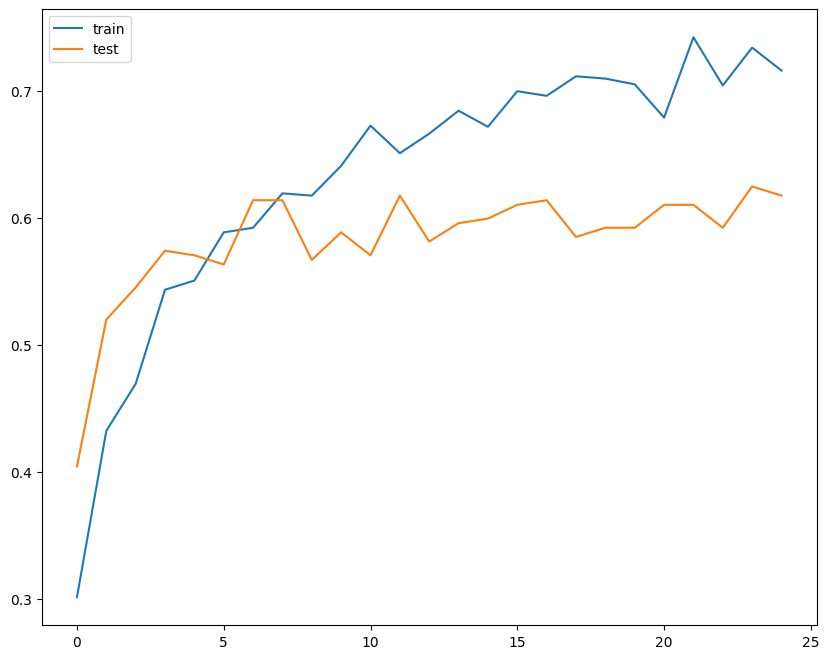

10/10 - 10s - 1s/step - accuracy: 0.5625 - loss: 1.1385
Test loss: 1.1385284662246704
Test accuracy: 0.5625
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 925ms/step


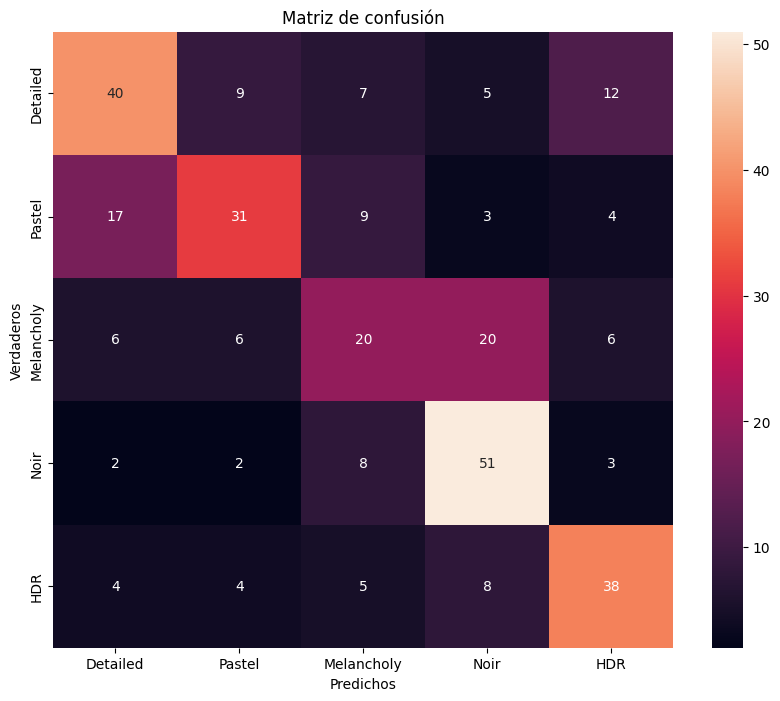

Accuracy para Detailed: 0.55
Accuracy para Pastel: 0.48
Accuracy para Melancholy: 0.34
Accuracy para Noir: 0.77
Accuracy para HDR: 0.64


In [50]:
# Graficamos la evolución de la función de pérdida y la precisión
plt.figure(figsize=(10, 8))
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.show()

# Evaluamos el modelo en el conjunto de test
test_loss, test_acc = model.evaluate(x_test_ft, y_test_ft, verbose=2)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

# Matriz de confusión del modelo

#Importamos las librerías necesarias
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predecimos las etiquetas de las imágenes de test
y_pred = model.predict(x_test_ft)
y_pred = np.argmax(y_pred, axis=1)

# Creamos la matriz de confusión
CM = confusion_matrix(y_test_ft, y_pred)

# Graficamos la matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(CM, annot=True, fmt='d', xticklabels=style_labels, yticklabels=style_labels)
plt.xlabel('Predichos')
plt.ylabel('Verdaderos')
plt.title('Matriz de confusión')
plt.show()

# Calculo de exactitud (Accuracy) por categoría
style_map = {i:j for i,j in enumerate(style_labels)}
def accuracy_by_category(y_true, y_pred):
    for i in style_map:
        true = y_true[y_true==i]
        pred = y_pred[y_true==i]
        acc = np.sum(true==pred)/len(true)
        print('Accuracy para %s: %.2f' % (style_map[i], acc))
        
accuracy_by_category(y_test_ft, y_pred)

Observando los resultados obtenidos, vemos que el modelo presenta una exactitud (accuracy) de 0.57 aproximadamente en promedio para la clasificación multiclase, lo cual podríamos considerar como un mal resultado. Si analizamos la capacidad del modelo de clasificar correctamente las imágenes para cada una de las categorías, vemos que el resultado mejora notablemente para las clases 'Noir' y 'HDR', mientras que vemos un resultado muy pobre para las clases 'Pastel' y especialmente para 'Melancoly'. Visto que la mayoría de las imágenes 'Melancoly' mal clasificadas se encuentran en la categoría 'Noir', podemos considerar que para la categoría 'Noir' el modelo presta especial atención a si la imagen está en blanco y negro o no, y aparentemente algunas de las imágenes del tipo 'Melancholy' lo están, cosa que se ve en las imágenes de ejemplo. Esto nos indica que el modelo no es capaz de distinguir entre 'Noir' y 'Melancholy' de manera precisa, por lo que el resultado general podemos entenderlo como pobre. Además, atendiendo a la evolución de la función de pérdida de la fase de valoración, podemos deducir que el modelo no podría mejorar siendo entrenado durante más épocas, dado que el descenso de la función de pérdida ya se ha estabilizado en esta fase.

<a id="section5"></a>
# <font color="#004D7F" size=5>Red opcional</font>

<a id="section5.1"></a>
## <font color="#004D7F" size=4>Ejercicio 7</font>

En este ejercicio tienes vía libre para crear una red que tu creas que va a funcionar mejor. Puedes usar una red construida desde 0 que tu creas que funcionará mejor o puedes usar un modelo pre-entrenado entre los que puedes seleccionar en `tf._keras.applications` que puedes ver [aquí](https://www.tensorflow.org/api_docs/python/tf/keras/applications).

Usa las capas que tú quieras y la configuración de entrenamiento que tu elijas.

In [121]:
from tensorflow.keras.layers import SeparableConv2D, BatchNormalization, DepthwiseConv2D, GlobalAveragePooling2D

# Definimos una nueva arquitectura de red neuronal con capas Depthwise Separable

model_ds = Sequential([
    InputLayer(shape=(150, 150, 3)),
    SeparableConv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D((2, 2), strides=2, padding='same'),
    
    SeparableConv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D((2, 2), strides=2, padding='same'),
    
    SeparableConv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling2D(),
    
    Dense(512, activation='relu'),
    Dropout(0.75),
    Dense(256, activation='relu'),
    Dropout(0.6),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
], name='flickr_style_model_ds')

model_ds.summary()


Model: "flickr_style_model_ds"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d_94             │ (None, 150, 150, 64)   │           283 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_322         │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_150               │ (None, 75, 75, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_95             │ (None, 75, 75, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_323         │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_151               │ (None, 38, 38, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_96             │ (None, 38, 38, 256)    │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_324         │ (None, 38, 38, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_28     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_148 (Dense)               │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_147 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_149 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_148 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_150 (Dense)               │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_149 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_151 (Dense)               │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,832 (1.24 MB)

 Trainable params: 323,936 (1.24 MB)

 Non-trainable params: 896 (3.50 KB)

In [122]:
# definimos el early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

# compilamos el modelo
model_ds.compile(
    optimizer= 'Adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamos el modelo
history_ds = model_ds.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 24s 627ms/step - accuracy: 0.2173 - loss: 1.7473 - val_accuracy: 0.1841 - val_loss: 1.6101
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 643ms/step - accuracy: 0.3283 - loss: 1.5824 - val_accuracy: 0.1841 - val_loss: 1.6104
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 644ms/step - accuracy: 0.3303 - loss: 1.5196 - val_accuracy: 0.1841 - val_loss: 1.6116
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 650ms/step - accuracy: 0.3729 - loss: 1.4602 - val_accuracy: 0.1841 - val_loss: 1.6124
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 665ms/step - accuracy: 0.3760 - loss: 1.4326 - val_accuracy: 0.1841 - val_loss: 1.6152
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 656ms/step - accuracy: 0.3985 - loss: 1.4662 - val_accuracy: 0.1841 - val_loss: 1.6157
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 637ms/step - accuracy: 0.4139 - loss: 1.4116 - val_accuracy: 0.1841 - val_loss: 1.6193
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 635ms/step - accuracy: 0.4875 - loss: 1.3542 - 

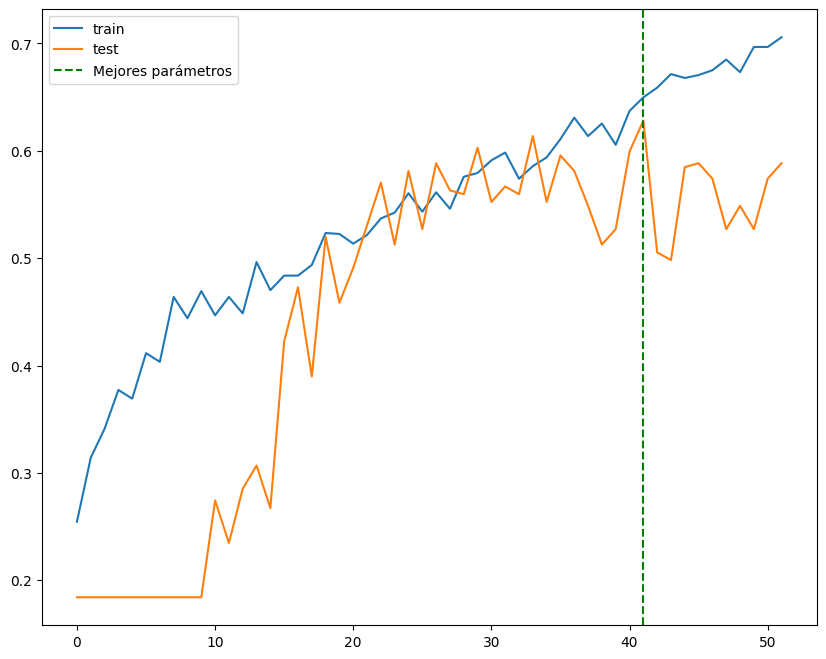

10/10 - 1s - 101ms/step - accuracy: 0.5813 - loss: 1.1788
Test loss: 1.1788276433944702
Test accuracy: 0.581250011920929
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step


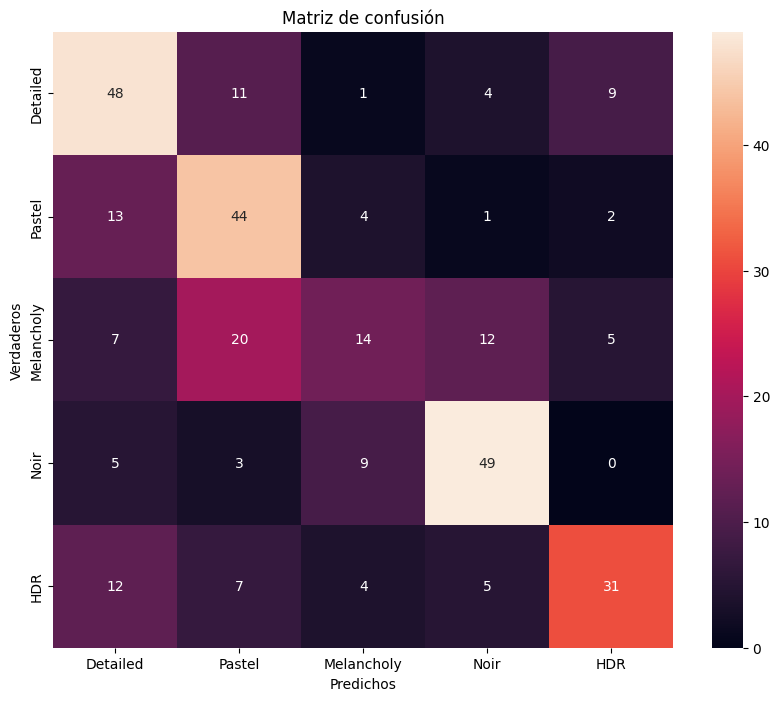

Accuracy para Detailed: 0.66
Accuracy para Pastel: 0.69
Accuracy para Melancholy: 0.24
Accuracy para Noir: 0.74
Accuracy para HDR: 0.53


In [123]:
# Graficamos la evolución de la función de pérdida y la precisión
plt.figure(figsize=(10, 8))
plt.plot(history_ds.history['accuracy'], label='train')
plt.plot(history_ds.history['val_accuracy'], label='test')
plt.axvline(x=len(history_ds.history['val_accuracy']) - early_stopping.patience - 1, color='green', linestyle='--', label='Mejores parámetros')
plt.legend()
plt.legend()
plt.show()

# Evaluamos el modelo en el conjunto de test
test_loss, test_acc = model_ds.evaluate(x_test, y_test, verbose=2)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

# Matriz de confusión del modelo

# Predecimos las etiquetas de las imágenes de test
y_pred_ds = model_ds.predict(x_test)
y_pred_ds = np.argmax(y_pred_ds, axis=1)

# Creamos la matriz de confusión
CM = confusion_matrix(y_test, y_pred_ds)

# Graficamos la matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(CM, annot=True, fmt='d', xticklabels=style_labels, yticklabels=style_labels)
plt.xlabel('Predichos')
plt.ylabel('Verdaderos')
plt.title('Matriz de confusión')
plt.show()

# Calculo de exactitud (Accuracy) por categoría
style_map = {i:j for i,j in enumerate(style_labels)}
def accuracy_by_category(y_true, y_pred):
    for i in style_map:
        true = y_true[y_true==i]
        pred = y_pred[y_true==i]
        acc = np.sum(true==pred)/len(true)
        print('Accuracy para %s: %.2f' % (style_map[i], acc))
        
accuracy_by_category(y_test, y_pred_ds)

<a id="section6"></a>
# <font color="#004D7F" size=5>¿Cuál es el mejor modelo?</font>

<a id="section6.1"></a>
## <font color="#004D7F" size=4>Ejercicio 8</font>

Una vez realizado todos los experimentos anteriores, ¿qué modelo elegirías para desplegar en producción? ¿Por qué?

Explica en breves palabras qué modelo eligirías para desplegar en producción y porqué. Compara cada experimento y extráe tus propias conclusiones.

En este caso, atendiendo a las diferentes métricas y gráficas para su comparación, el mejor modelo es la red personalizada. En la misma he implementado capas convolucionales de tipo Depthwise separable, que incorpora una convolución separada por canal seguida de una convolución pointwise (convolución de kernel 1x1) que reconstituye los datos de todos los canales. Este tipo de red realiza la misma operación que una convolucional estandar pero con muchos menos parámetros, lo que permite optimizar el peso de la red, que como vemos es de 1,24 MB, siendo la más ligera de todas. Atendiendo a las métricas, la precisión es la más alta de todos los modelos, aunque muestra un problema similar en la clasificación de la clase 'Melancholy'. El tiempo de entrenamiento también es más breve, siendo la mitad por cada época comparada con el entrenamiento de la red usada en fine-tunning, aunque el tiempo total final sea similar. En conclusión, esta arquitectura parece prometedora, y estaría muy indicada para desplegarla en dispositivos cuyo hardware fuera limitado, como teléfonos móviles u ordenadores personales. 